Run with cruzain_2020_env

## Install and import modules

In [1]:
# Print versions used in the Notebook
# Python
import sys
print('Python: {}'.format(sys.version))
# numpy
import numpy as np
print('numpy: {}'.format(np.__version__))
# pandas
import pandas as pd
print('pandas: {}'.format(pd.__version__))
# scikit-learn
import sklearn
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.7.16 (default, Jan 17 2023, 16:06:28) [MSC v.1916 64 bit (AMD64)]
numpy: 1.21.5
pandas: 1.3.5
sklearn: 0.24.1


In [2]:
import ast  # convert fingerprints from strings to lists
import matplotlib.pyplot as plt
# models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# training
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import *
# assess calibration 
from sklearn.calibration import calibration_curve

In [3]:
# Display complete pandas DataFrames
pd.options.display.max_rows = None
pd.options.display.max_columns = None
plt.rcParams['figure.dpi'] = 200
plt.rcParams["figure.figsize"] = (5,4)

## Define model quality metrics

In [4]:
# Dictionary with metrics and labels
metrics_d = {'Precision': 'precision',
             'Accuracy': 'accuracy',
             'F1': make_scorer(f1_score),
             'Kappa': make_scorer(cohen_kappa_score),
             'MCC': make_scorer(matthews_corrcoef),
             'ROC/AUC': 'roc_auc',
             'Recall': 'recall'}

# Import datasets

In [5]:
# Import dataset
df = pd.read_csv(f'cruzain_26_neq_fps.csv', sep=";")
df.head()

,pchembl_value,standard_SMILES,fp
0,6.42,CC(C)N1CC(=O)C(NC(=O)C(Cc2ccccc2)NC(=O)OCc2ccc...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
1,7.28,O=C(NC(Cc1ccccc1)C(=O)NC1CC(=O)N(CCc2ccccc2)CC...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,8.38,O=C(NC(Cc1ccccc1)C(=O)NC(Cc1ccccc1)C(=O)CSCCc1...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,6.01,COCCN1CC(=O)C(NC(=O)C(Cc2ccccc2)NC(=O)OCc2cccc...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
4,6.44,CCCN1CC(=O)C(NC(=O)C(Cc2ccccc2)NC(=O)OCc2ccccc...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."


In [6]:
# Convert the column containing the fingerprints as strings to lists, then to DataFrame with Morgan FPs
fps_list = [ast.literal_eval(string_list) for string_list in df['fp'].tolist()]
X = pd.DataFrame(fps_list, columns=[str(i) for i in range(1024)])
X.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021

In [7]:
# Define binary target
y_cont = df['pchembl_value'].copy()
y = y_cont >= 6.0
y = y.astype(int)

In [8]:
print("Actives:", y.sum())
print("Inactives:", len(y) - y.sum())

Actives: 324
Inactives: 283


In [9]:
# Split training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Define classifier objects
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
svc_classifier = SVC(kernel='linear', random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Define stratified cross-validation object
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
# Evaluate a model with cross-validation on the training set and print results
def evaluate_model(model, X_train, y_train, cv, scoring):
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    for k, v in cv_scores.items():
        if k in ['fit_time', 'score_time']:
            continue
        print(f"{k[5:]} score: {np.mean(v):.3f} ({1.96 * np.std(v):.3f})")

In [11]:
evaluate_model(lr_classifier, X_train, y_train, cv=stratified_cv, scoring=metrics_d)

Precision score: 0.785 (0.022)
Accuracy score: 0.788 (0.045)
F1 score: 0.806 (0.047)
Kappa score: 0.572 (0.090)
MCC score: 0.574 (0.095)
ROC/AUC score: 0.879 (0.051)
Recall score: 0.830 (0.086)


In [12]:
evaluate_model(svc_classifier, X_train, y_train, cv=stratified_cv, scoring=metrics_d)

Precision score: 0.761 (0.044)
Accuracy score: 0.748 (0.073)
F1 score: 0.764 (0.093)
Kappa score: 0.495 (0.140)
MCC score: 0.499 (0.142)
ROC/AUC score: 0.825 (0.068)
Recall score: 0.773 (0.180)


In [13]:
evaluate_model(rf_classifier, X_train, y_train, cv=stratified_cv, scoring=metrics_d)

Precision score: 0.788 (0.086)
Accuracy score: 0.812 (0.078)
F1 score: 0.836 (0.062)
Kappa score: 0.619 (0.162)
MCC score: 0.626 (0.154)
ROC/AUC score: 0.886 (0.038)
Recall score: 0.892 (0.038)


We choose the Random Forest classifier

In [14]:
model = rf_classifier

## Evaluate model with y-scrambling

In [15]:
y_scrambled = y_train.sample(frac=1, random_state=42)

evaluate_model(model, X_train, y_scrambled, cv=stratified_cv, scoring=metrics_d)

Precision score: 0.501 (0.025)
Accuracy score: 0.466 (0.032)
F1 score: 0.515 (0.029)
Kappa score: -0.079 (0.079)
MCC score: -0.080 (0.080)
ROC/AUC score: 0.437 (0.055)
Recall score: 0.533 (0.071)


## Predict test set

In [16]:
# Best model
model = rf_classifier.fit(X_train, y_train)

In [17]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[50  7]
 [ 5 60]]


In [18]:
precision_score(y_test, y_pred)

0.8955223880597015

In [19]:
from sklearn.metrics import precision_score, accuracy_score, f1_score, cohen_kappa_score, matthews_corrcoef, roc_auc_score, recall_score, make_scorer

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

metrics_test = {
    'Precision': precision_score,
    'Accuracy': accuracy_score,
    'F1': f1_score,
    'Kappa': cohen_kappa_score,
    'MCC': matthews_corrcoef,
    'ROC/AUC': roc_auc_score,
    'Recall': recall_score
}

# Calculate and print the metrics
results_test = {}
for metric_name, metric_func in metrics_test.items():
    if metric_name == 'ROC/AUC':
        # For ROC/AUC, you need to pass the probability scores and the true labels
        results_test[metric_name] = metric_func(y_test, y_pred_proba[:, 1])
    else:
        results_test[metric_name] = metric_func(y_test, y_pred)

# Print the results
for metric_name, metric_value in results_test.items():
    print(f"{metric_name}: {metric_value:.3f}", end=", ")

Precision: 0.896, Accuracy: 0.902, F1: 0.909, Kappa: 0.802, MCC: 0.802, ROC/AUC: 0.949, Recall: 0.923, 

# Evaluate calibration

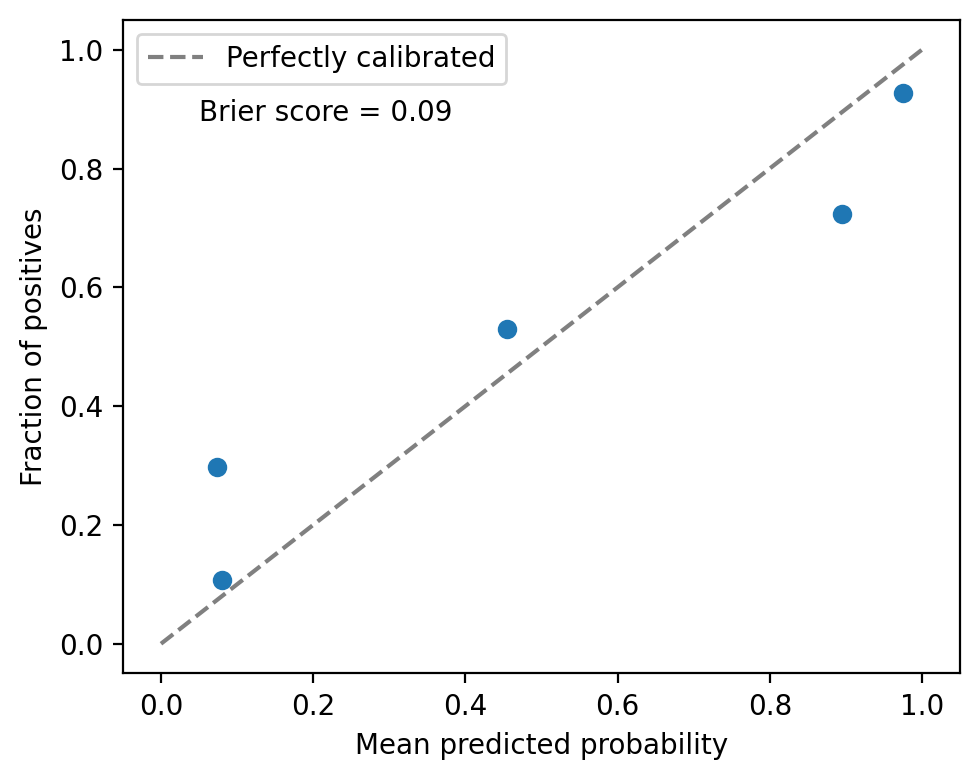

In [37]:
# Calibration curve
y_true = y_test
y_pred_proba = model.predict_proba(X_test)
y_prob_1 = [val[1] for val in y_pred_proba]

prob_true, prob_pred = calibration_curve(y_true, y_prob_1, n_bins=5)

# Brier score: closer to 0 = better calibration
brier_score = brier_score_loss(y_true, y_prob_1)  

# Plot calibration curve
plt.scatter(prob_true, prob_pred)
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated', color='gray')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.text(0.05, 0.88, f'Brier score = {brier_score:.2f}', fontsize=10, color='black')
plt.tight_layout()
plt.savefig('calib_plot.png')
plt.show()

# Predict cruzain activity on antivirals dataset

## Fit final model on entire dataset

In [21]:
# Fit final model on entire dataset
model = rf_classifier
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [22]:
antivirals_std = pd.read_csv("antivirals_std.csv", sep=';')
antivirals_std.head(2)

,Name,standard_SMILES,fp
0,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCC3=O)cc(Cl)c1F)c(=O)c(C...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
1,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCC3)cc(Cl)c1F)c(=O)c(C(=...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


In [23]:
# Convert the strings on fp column to lists
antivirals_fps = [ast.literal_eval(string_list) for string_list in antivirals_std['fp'].tolist()]

# Create dataframe, use column names in X
antivirals_fps = pd.DataFrame(antivirals_fps, columns=[str(i) for i in range(1024)])
antivirals_fps.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021

In [24]:
# Calculate scores: probabilities to be in class 1
pred_proba = model.predict_proba(antivirals_fps)
scores = [val[1] for val in pred_proba]

# Get scores from approved drugs on the DrugBank database

In [25]:
drugbank = pd.read_csv("drugbank_fps.csv", sep=";")

In [26]:
drugbank_smi = drugbank[['Name', 'standard_SMILES']].copy()

In [27]:
# Copy dataset
antivirals_std_preds = antivirals_std.copy()

# Reorder by descending value of prediction score
antivirals_std_preds['score'] = scores
antivirals_std_preds = antivirals_std_preds.sort_values(by="score", ascending=False)[["standard_SMILES", "score"]]

In [28]:
matched_rows = pd.merge(antivirals_std_preds, drugbank_smi, on='standard_SMILES')
matched_rows.shape

(96, 3)

In [29]:
matched_rows.head(20)

,standard_SMILES,score,Name
0,CC(C)CN(CC(OP(=O)(O)O)C(Cc1ccccc1)NC(=O)OC1CCO...,0.66,Fosamprenavir
1,CC(C)CN(CC(O)C(Cc1ccccc1)NC(=O)OC1CCOC1)S(=O)(...,0.66,Amprenavir
2,CC(C)(C)NC(=O)NC(C(=O)N1CC2C(C1C(=O)NC(CC1CCC1...,0.66,Boceprevir
3,CC(C)CN(CC(O)C(Cc1ccccc1)NC(=O)OC1COC2OCCC12)S...,0.58,Darunavir
4,CC(C)(C)NC(=O)C1CC2CCCCC2CN1CC(O)C(Cc1ccccc1)N...,0.58,Saquinavir
5,CC(C)c1nc(CN(C)C(=O)NC(C(=O)NC(Cc2ccccc2)CC(O)...,0.54,Ritonavir
6,COC(=O)NC(C(=O)N1CC2(CC2)CC1c1nc(-c2ccc3c(c2)C...,0.52,Ledipasvir
7,COCC1CC(c2nc(-c3ccc4c(c3)COc3cc5c(ccc6[nH]c(C7...,0.52,Velpatasvir
8,Cc1nnc(C(C)C)n1C1CC2CCC(C1)N2CCC(NC(=O)C1CCC(F...,0.51,Maraviroc
9,CC(C)c1nc(CN(C)C(=O)NC(CCN2CCOCC2)C(=O)NC(CCC(...,0.51,Cobicistat
